In [ ]:
# Import libraries
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score
)

PART 1 - DATA COLLECTION AND DATA UNDERSTANDING

In [ ]:
!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('zara2099/scada-pipeline-operations-dataset')


files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

print(f"Dataset loaded successfully: {df.shape}")

Using Colab cache for faster access to the 'scada-pipeline-operations-dataset' dataset.
Dataset loaded successfully: (1000, 13)


In [ ]:
df.head()

,timestamp,segment_id,pressure,flow_rate,temperature,valve_status,pump_state,pump_speed,compressor_state,energy_consumption,alarm_triggered,event_type,target
0,1/1/2024 0:00,34,71.63,3.07,33.61,1,1,1385.6,1,36.32,0,normal,0
1,1/1/2024 0:00,15,71.28,4.61,31.96,0,1,1422.1,1,33.40,0,normal,0
2,1/1/2024 0:00,42,68.60,4.55,33.21,2,0,0.0,0,11.09,0,normal,0
3,1/1/2024 0:00,16,98.49,1.61,30.61,2,1,1368.7,1,37.07,1,blockage,1
4,1/1/2024 0:00,7,81.63,4.95,32.51,1,0,0.0,0,11.21,0,normal,0


In [ ]:
df.columns

Index(['timestamp', 'segment_id', 'pressure', 'flow_rate', 'temperature',
       'valve_status', 'pump_state', 'pump_speed', 'compressor_state',
       'energy_consumption', 'alarm_triggered', 'event_type', 'target'],
      dtype='object')

In [ ]:
df.dtypes

,0
timestamp,object
segment_id,int64
pressure,float64
flow_rate,float64
temperature,float64
valve_status,int64
pump_state,int64
pump_speed,float64
compressor_state,int64
energy_consumption,float64


This is a pipeline dataset that contains different features to predict whether a pipeline is faulty or not.

The dataset represents real time sensor monitoring from a SCADA system. it's a multivariate, multi-segment, time-series classification dataset where each observation is a sensor reading from one pipeline segment at one point in time, and the task is to classify whether that segment is experiencing a fault.

TASK 2 - DATA CLEANING AND PREPROCESSING

In [ ]:
# Converting to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values("timestamp")

In [ ]:
print(df['timestamp'].nunique())

17


After inspecting the timestamp column and only the mkinute was changing and the rest was constant. The changes with respect to minute were minimal so, dropping the whole timestamp column is the most beneficial thing to do

In [ ]:
# Checking missing values
df.isnull().sum()

,0
timestamp,0
segment_id,0
pressure,0
flow_rate,0
temperature,0
valve_status,0
pump_state,0
pump_speed,0
compressor_state,0
energy_consumption,0


In [ ]:
print(df.isnull().sum())
print(df.isnull().sum().sum())  # should print 0

timestamp             0
segment_id            0
pressure              0
flow_rate             0
temperature           0
valve_status          0
pump_state            0
pump_speed            0
compressor_state      0
energy_consumption    0
alarm_triggered       0
event_type            0
target                0
dtype: int64
0


In [ ]:
# Checking for duplicates
print(df.duplicated().sum())

0


No missing values or duplicates in our dataset

In [ ]:
# Dropping columns
df = df.drop(["timestamp", "event_type", "alarm_triggered"], axis=1)

I dropped the timestamp column simply because they were almost all the same except for the minutes and after checking the minutes individually, their distances or differences were very minimal.

I also dropped event_type column because it would cause data leakage for our model. It is simply given the predictions out before we predict and it will perform poorly on a test data.

TASK 3 - EXPLORATORY DATA ANALYSIS

In [ ]:
df.describe()

,segment_id,pressure,flow_rate,temperature,valve_status,pump_state,pump_speed,compressor_state,energy_consumption,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,25.746000,76.202520,4.359050,32.097720,0.916000,0.689000,937.191700,0.600000,26.853490,0.30600
std,14.324199,9.481698,0.894735,1.976705,0.548858,0.463134,640.752405,0.490143,9.270165,0.46106
min,1.000000,43.110000,1.010000,25.920000,0.000000,0.000000,0.000000,0.000000,5.420000,0.00000
25%,14.000000,71.127500,4.040000,30.690000,1.000000,0.000000,0.000000,0.000000,20.982500,0.00000
50%,25.000000,75.350000,4.500000,32.125000,1.000000,1.000000,1304.150000,1.000000,26.260000,0.00000
75%,38.000000,79.282500,4.880000,33.395000,1.000000,1.000000,1418.025000,1.000000,33.942500,1.00000
max,50.000000,115.300000,7.530000,38.520000,2.000000,1.000000,1678.800000,1.000000,58.180000,1.00000


In [ ]:
# Percentage of faulty pipe(1) to healthy pipe(0)
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.694
1,0.306


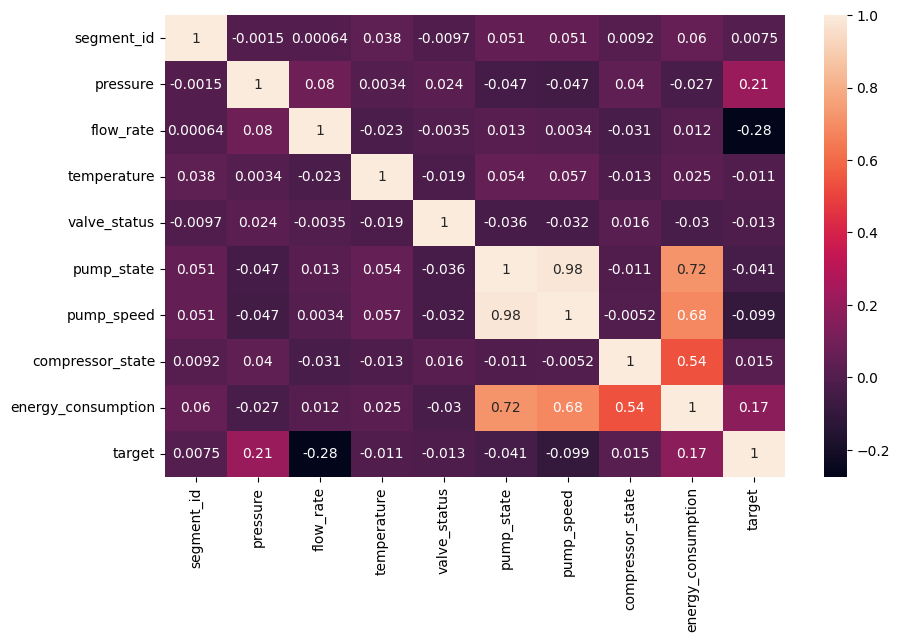

In [ ]:
# Correlation heatmap using seaborn
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
print(df.corr()['target'].sort_values(ascending=False))

target                1.000000
pressure              0.214237
energy_consumption    0.173902
compressor_state      0.015060
segment_id            0.007537
temperature          -0.010788
valve_status         -0.013038
pump_state           -0.041412
pump_speed           -0.098904
flow_rate            -0.275917
Name: target, dtype: float64


In [ ]:
# Checking outliers
numeric_cols = ['pressure', 'flow_rate', 'temperature', 'pump_speed', 'energy_consumption']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

pressure: 100 outliers
flow_rate: 81 outliers
temperature: 6 outliers
pump_speed: 0 outliers
energy_consumption: 4 outliers


In [ ]:
# Feature engineering
df['pressure_flow_ratio'] = df['pressure'] / (df['flow_rate'] + 1e-6)

In [ ]:
df['high_energy_low_flow'] = (
    (df['energy_consumption'] > df['energy_consumption'].quantile(0.75)) &
    (df['flow_rate'] < df['flow_rate'].quantile(0.25))
).astype(int)

In [ ]:
df.isnull().sum()

,0
segment_id,0
pressure,0
flow_rate,0
temperature,0
valve_status,0
pump_state,0
pump_speed,0
compressor_state,0
energy_consumption,0
target,0


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Preprocessing using Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

PREDICTIVE MODEL

In [ ]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=1000, class_weight="balanced")
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [ ]:
y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
results = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred_lr,
    "Probability" : y_proba_lr
})
display(results.head(10))

,Actual,Predicted,Probability
767,0,0,0.183346
340,0,1,0.559880
615,0,0,0.184365
787,0,0,0.259739
12,0,0,0.250465
25,0,1,0.552315
469,1,1,0.872994
218,0,0,0.095940
705,0,0,0.279937
778,0,0,0.156010


In [ ]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : model_lr.coef_[0]
})
display(feature_importance.sort_values(by="Importance", ascending=False))

,Feature,Importance
9,pressure_flow_ratio,3.458366
8,energy_consumption,2.583950
2,flow_rate,0.695120
10,high_energy_low_flow,0.240730
5,pump_state,0.180643
4,valve_status,0.036673
3,temperature,-0.004265
0,segment_id,-0.074062
1,pressure,-0.244082
7,compressor_state,-1.449057


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       139
           1       0.73      0.75      0.74        61

    accuracy                           0.84       200
   macro avg       0.81      0.82      0.81       200
weighted avg       0.84      0.84      0.84       200



In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42, class_weight="balanced")
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test_scaled)

In [ ]:
 y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

In [ ]:
results_dt = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred_dt,
    "Probability" : y_proba_dt
})
display(results_dt.head(10))

,Actual,Predicted,Probability
767,0,0,0.043581
340,0,0,0.212400
615,0,0,0.043581
787,0,0,0.043581
12,0,0,0.043581
25,0,0,0.212400
469,1,1,0.993821
218,0,1,0.798561
705,0,0,0.043581
778,0,1,0.660059


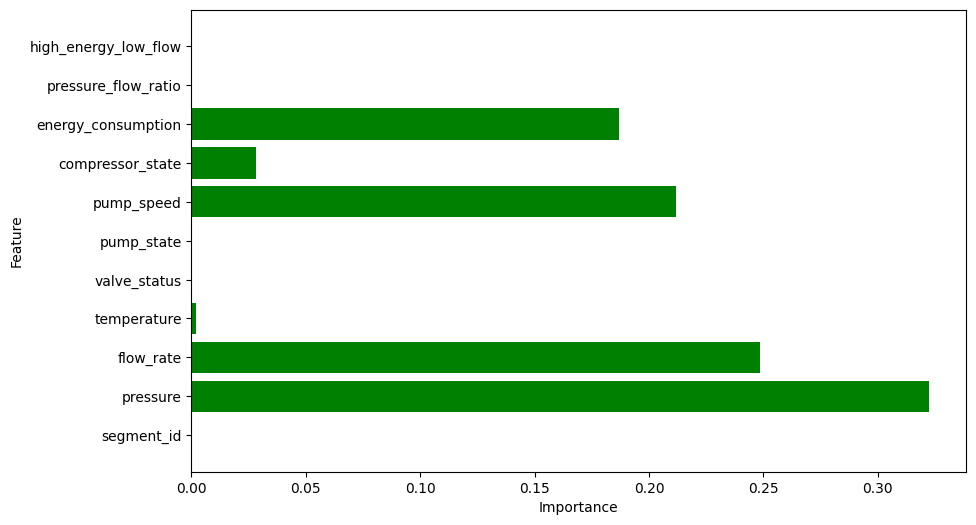

In [ ]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : dt.feature_importances_
})

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="green")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       139
           1       0.84      0.89      0.86        61

    accuracy                           0.92       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.92      0.92      0.92       200



In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[129  10]
 [  7  54]]


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
results_rf = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred_rf,
    "Probability" : y_proba_rf
})
display(results_rf.head(10))

,Actual,Predicted,Probability
767,0,0,0.139264
340,0,0,0.363281
615,0,0,0.174711
787,0,0,0.126430
12,0,0,0.141469
25,0,0,0.325287
469,1,1,0.815219
218,0,0,0.296495
705,0,0,0.131216
778,0,0,0.367530


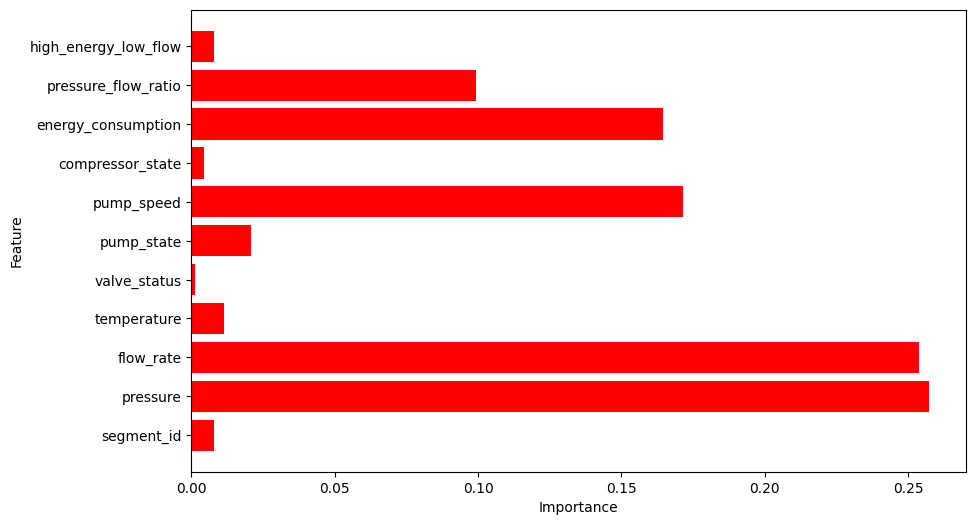

In [ ]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : rf.feature_importances_
})

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="red")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       139
           1       0.95      0.95      0.95        61

    accuracy                           0.97       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.97      0.97      0.97       200



In [ ]:
# Comparing each model evaluation metrics
def evaluate_model(name, y_true, y_pred, y_proba):
  return{
     "model" : name,
     "accuracy" : accuracy_score(y_true, y_pred),
     "precision" : precision_score(y_true, y_pred),
     "recall" : recall_score(y_true, y_pred),
     "f1" : f1_score(y_true, y_pred),
     "roc-auc" : roc_auc_score(y_true, y_proba)
  }

In [ ]:

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
])
display(results.round(5))

,model,accuracy,precision,recall,f1,roc-auc
0,Logistic Regression,0.840,0.73016,0.75410,0.74194,0.88796
1,Decision Tree,0.915,0.84375,0.88525,0.86400,0.91980
2,Random Forest,0.970,0.95082,0.95082,0.95082,0.98585


Random Forest performed the best and then we go ahead to deploy our model(Random Forest) to be used for predictions.

DEPLOYMENT

In [ ]:
# Saving our model and scaler
import joblib
model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight="balanced")
model.fit(X_train_scaled, y_train)

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully")

Model and scaler saved successfully


In [ ]:
!pip install streamlit --quiet

In [ ]:
# Creating our app.py used to create interface for testing
%%writefile app.py
import joblib
import streamlit as st
import pandas as pd
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
st.title("Pipeline Fault Prediction")

segment_id = st.number_input("Segment ID", value=50.00)
pressure = st.number_input("Pressure", value=116.00)
flow_rate = st.number_input("flow_rate", value=8.00)
temperature = st.number_input("Temperature", value=39.00)
valve_status = st.number_input("Valve Status", value=2.00)
pump_state = st.number_input("Pump State", value=1.00)
pump_speed = st.number_input("Pump Speed", value=1680.00)
compressor_state = st.number_input("Compressor State", value=1.00)
energy_consumption = st.number_input("Energy Consumption", value=59.00)
pressure_flow_rate = st.number_input("Pressure Flow Rate", value=96.00)
high_energy_low_flow = st.number_input("High Energy Low Flow", value=1.00)

if st.button("Predict"):
  input_data = pd.DataFrame([[segment_id, pressure, flow_rate, temperature, valve_status, pump_state, pump_speed, compressor_state, energy_consumption, pressure_flow_rate, high_energy_low_flow]])
  input_scaled = scaler.transform(input_data)
  prediction = model.predict(input_scaled)

  if prediction[0] == 0:
    st.success("Normal - This pipeline segment is operating normally.")
  else:
    st.error("Fault Detected - This pipeline segment is faulty.")

Overwriting app.py


In [381]:
# Creating requirements
%%writefile requirements.txt
streamlit
scikit-learn
pandas
numpy
joblib

Overwriting requirements.txt
